In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('ecommerce_data.csv')
df.head(5)

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [3]:
df.isnull().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

In [4]:
df.shape

(500, 8)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [7]:
len(df['Email'].unique())

500

In [8]:
df.drop(columns=['Email', 'Address', 'Avatar'], inplace=True)

In [9]:
df.head(5)

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


In [10]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [11]:
import matplotlib.pyplot as plt 
import seaborn as sns

<Axes: xlabel='Avg. Session Length', ylabel='Count'>

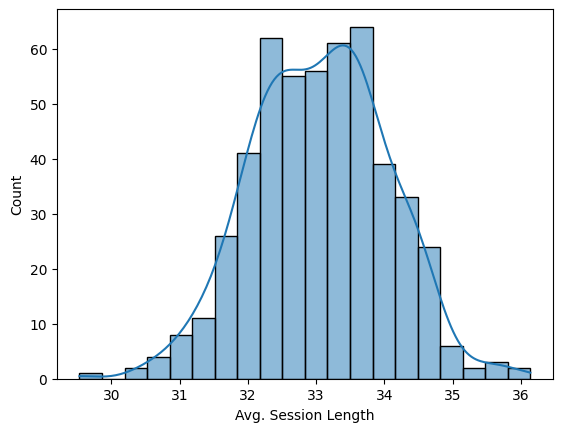

In [12]:
sns.histplot(x=df['Avg. Session Length'], data=df, kde=True)

In [13]:
df['Avg. Session Length'].skew()

np.float64(-0.03217480705175727)

<Axes: xlabel='Time on App', ylabel='Count'>

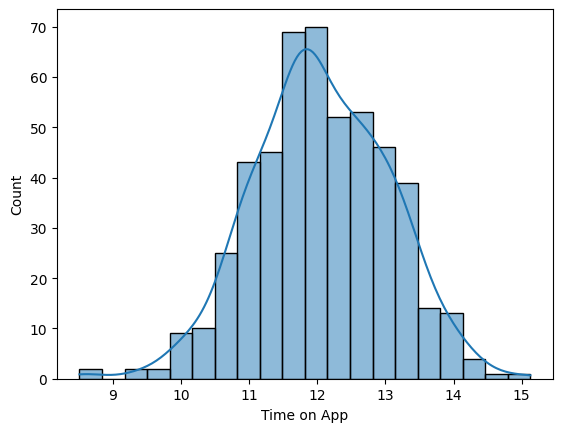

In [14]:
sns.histplot(x=df['Time on App'], data=df, kde=True)

In [15]:
df['Time on App'].skew()

np.float64(-0.08912109751093247)

<Axes: xlabel='Time on Website', ylabel='Count'>

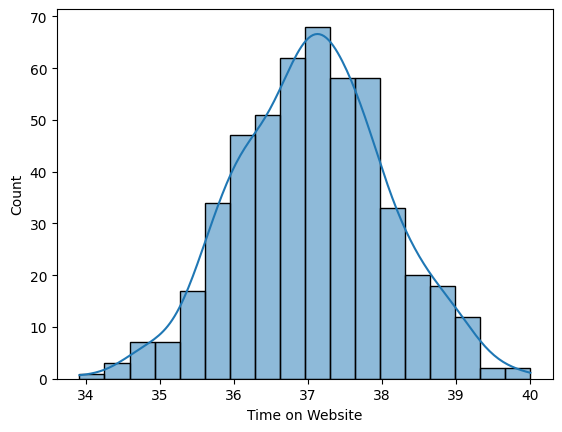

In [16]:
sns.histplot(x=df['Time on Website'], data=df, kde=True)

In [17]:
df['Time on Website'].skew()

np.float64(0.012141880271484171)

### Conclusion
    So all the data is the normal distributed because it's tends to 0 or near to zero

<Figure size 500x500 with 0 Axes>

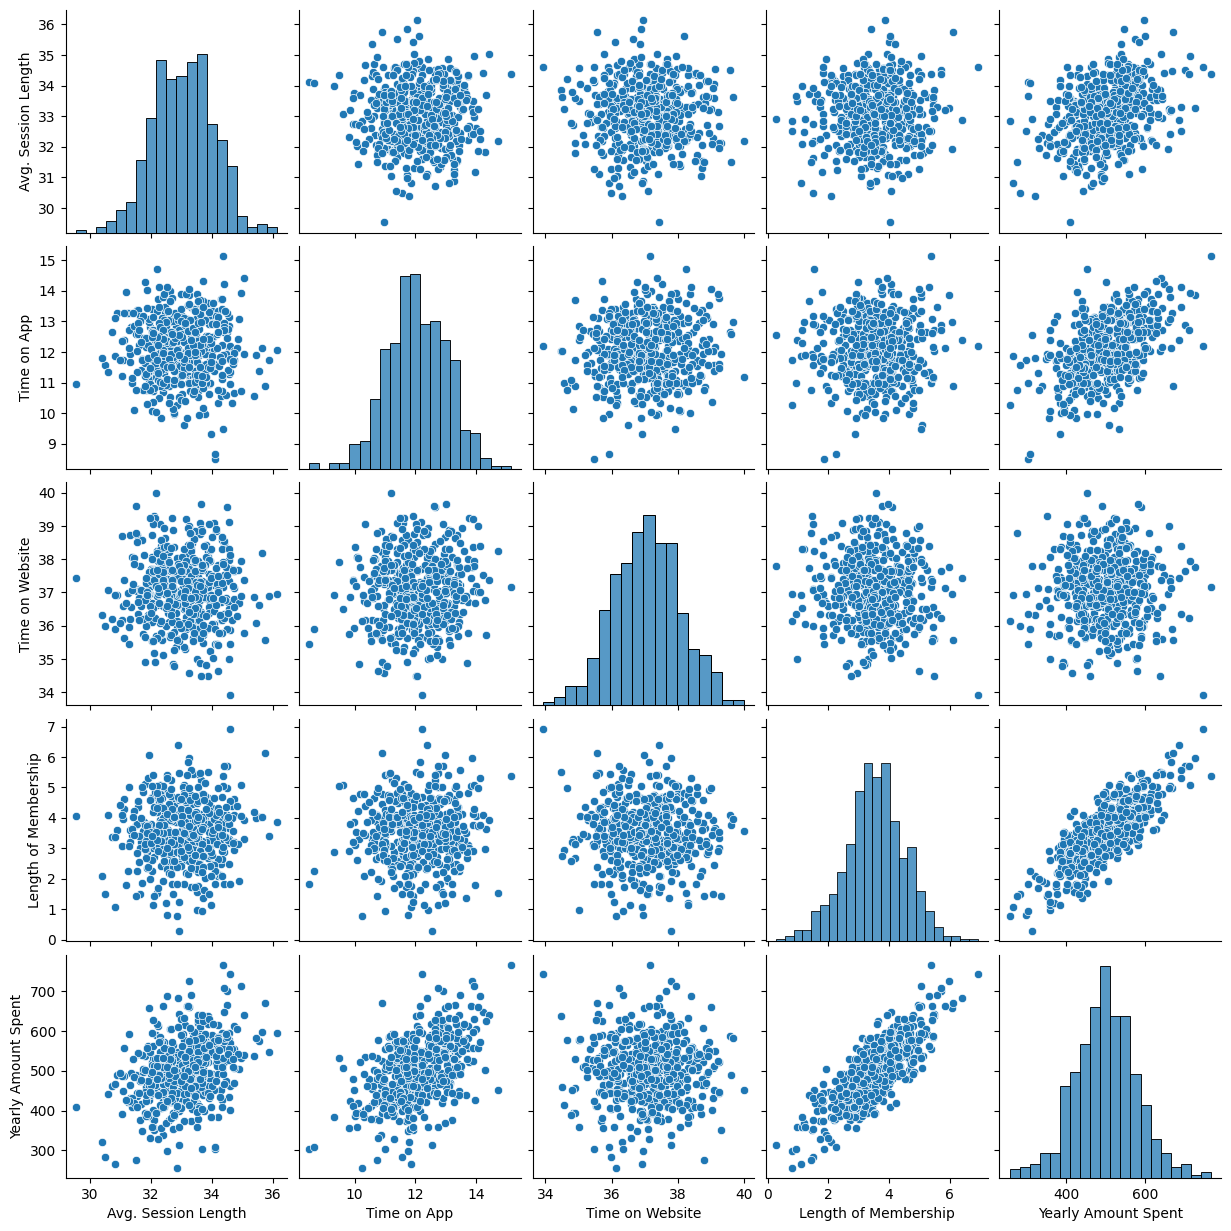

In [18]:
plt.figure(figsize=(5, 5))
sns.pairplot(df)

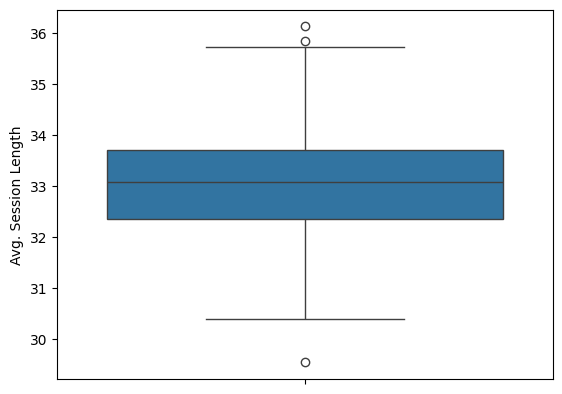

In [19]:
sns.boxplot(df['Avg. Session Length'])
plt.show()

<Axes: ylabel='Length of Membership'>

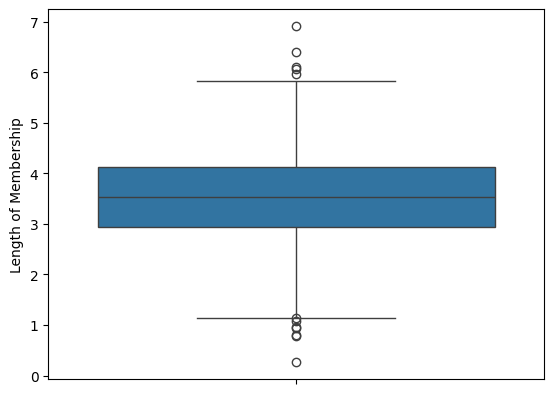

In [20]:
sns.boxplot(df['Length of Membership'])

<Axes: ylabel='Time on App'>

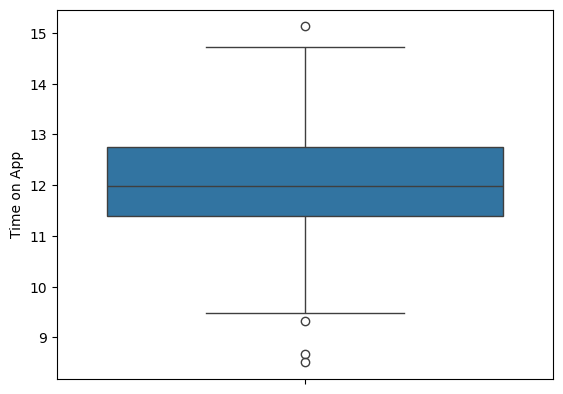

In [21]:
sns.boxplot(df['Time on App'])

<Axes: ylabel='Time on Website'>

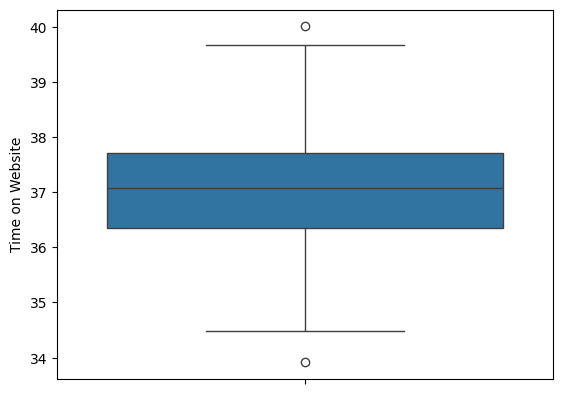

In [22]:
sns.boxplot(df['Time on Website'])

In [23]:
df.shape

(500, 5)

In [24]:
## Removing Outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [25]:
df.shape  ### Here we have 24 outliers in the dataset

(476, 5)

In [26]:
!pip install statsmodels


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

x = df.drop('Yearly Amount Spent', axis=1)
x = sm.add_constant(x)

vif_data = pd.DataFrame()
vif_data['feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

In [28]:
vif_data ## our data has no multicollinearity   

,feature,VIF
0,const,2796.523836
1,Avg. Session Length,1.001601
2,Time on App,1.008345
3,Time on Website,1.006150
4,Length of Membership,1.004977


<Axes: >

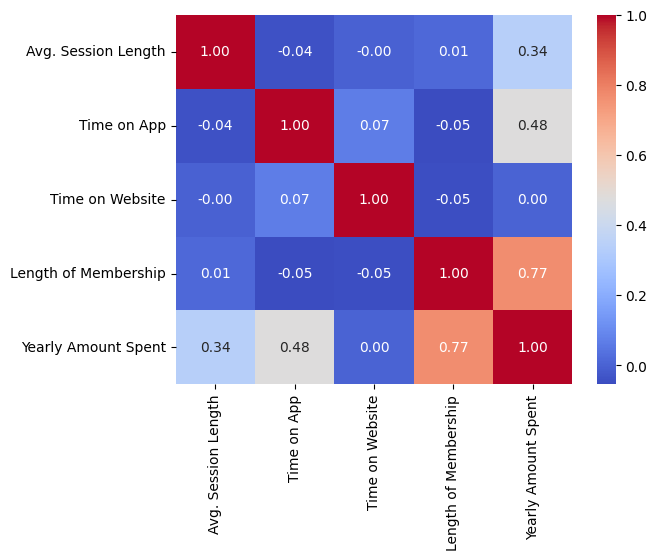

In [29]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [30]:
corr = df.corrwith(df['Yearly Amount Spent'])
corr

Avg. Session Length     0.339804
Time on App             0.475560
Time on Website         0.000581
Length of Membership    0.767651
Yearly Amount Spent     1.000000
dtype: float64

In [31]:
X = df.drop('Yearly Amount Spent', axis=1)
y = df['Yearly Amount Spent']

In [32]:
X

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573
496,34.702529,11.695736,37.190268,3.576526
497,32.646777,11.499409,38.332576,4.958264
498,33.322501,12.391423,36.840086,2.336485


In [33]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [34]:
model = LinearRegression()


In [35]:
rfe = RFE(model, n_features_to_select=3)

In [36]:
rfe = rfe.fit(X, y)
selected_features_rfe = X.columns[rfe.support_]

In [37]:
print("Selected features rfe")
print(selected_features_rfe)

Selected features rfe
Index(['Avg. Session Length', 'Time on App', 'Length of Membership'], dtype='object')


In [38]:
new_df = df[selected_features_rfe]
new_df['Yearly Amount Spent'] = df['Yearly Amount Spent']
new_df.head(5)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_18232\1198020649.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['Yearly Amount Spent'] = df['Yearly Amount Spent']


,Avg. Session Length,Time on App,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,4.082621,587.951054
1,31.926272,11.109461,2.664034,392.204933
2,33.000915,11.330278,4.104543,487.547505
3,34.305557,13.717514,3.120179,581.852344
4,33.330673,12.795189,4.446308,599.406092


In [39]:
X = new_df.drop('Yearly Amount Spent', axis=1)
y = new_df['Yearly Amount Spent']

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [43]:
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge' : Ridge(),
    'Lasso' : Lasso(),
    'ElasticNet' : ElasticNet()
}

models.items()

dict_items([('LinearRegression', LinearRegression()), ('Ridge', Ridge()), ('Lasso', Lasso()), ('ElasticNet', ElasticNet())])

In [44]:
for name, model in models.items():
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    score = r2_score(y_test, y_pred)

    print(f"{name} : Mean square error : {mse:.2f}, Mean absolute error : {mae:.2f}, R2 Score : {score:2f}")

LinearRegression : Mean square error : 104.97, Mean absolute error : 8.07, R2 Score : 0.978900
Ridge : Mean square error : 104.92, Mean absolute error : 8.08, R2 Score : 0.978909
Lasso : Mean square error : 106.20, Mean absolute error : 8.25, R2 Score : 0.978652
ElasticNet : Mean square error : 739.15, Mean absolute error : 22.21, R2 Score : 0.851416


### The conclusion is the Linear Regression and Ridge are performing better than the Lasso , Elasticnet

    But the problem is that if the model are overfitting, to avoid this we do hyperparameter tunning on Elasticnet because in Elasticnet we have two parameter alpha and l1 ratio so we use this for hyperparameter tunning..

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
X = new_df.drop('Yearly Amount Spent', axis=1)
y = new_df['Yearly Amount Spent']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
elasticnet = ElasticNet()

param_grid = {
    'alpha' : [0.1, 0.5, 1.0, 5.0, 10.0],
    'l1_ratio' : [0.1, 0.5, 0.9]
}

gridsearch = GridSearchCV(estimator=elasticnet, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error')

gridsearch.fit(X_train, y_train)

print(f"Best parameter : {gridsearch.best_params_}")
print(f"Best Score : {gridsearch.best_score_}")

Best parameter : {'alpha': 0.1, 'l1_ratio': 0.9}
Best Score : -8.0833267535163


In [50]:
best_model = gridsearch.best_estimator_

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_pred, y_test)
mae = mean_absolute_error(y_pred, y_test)
score = r2_score(y_pred, y_test)

print(f"MSE : {mse}, MAE : {mae}, R2_score : {score}")

MSE : 105.27724853939134, MAE : 8.154181367631141, R2_score : 0.9779259264749073


In [51]:
new_df.head(5)

,Avg. Session Length,Time on App,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,4.082621,587.951054
1,31.926272,11.109461,2.664034,392.204933
2,33.000915,11.330278,4.104543,487.547505
3,34.305557,13.717514,3.120179,581.852344
4,33.330673,12.795189,4.446308,599.406092


In [52]:
data = np.array([31.926272,	11.109461,	2.664034	]).reshape(1, -1)

In [53]:
new_data = scaler.transform(data)

c:\Users\ASUS\Desktop\projects\Macchine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [54]:
new_data

array([[-1.16993512, -0.99774892, -0.96604312]])

In [55]:
best_model.predict(new_data)

array([381.77934589])

In [56]:
import pickle

In [63]:
with open('scaler.pkl', 'wb') as scaler_files:
    pickle.dump(scaler, scaler_files)

In [64]:
with open('best_model.pkl', 'wb') as model_files:
    pickle.dump(best_model, model_files)

In [65]:
with open('scaler.pkl', 'rb') as scaler_files:
    loded_scaler = pickle.load(scaler_files)

with open('best_model.pkl', 'rb') as model_files:
    loded_model = pickle.load(model_files)

In [66]:
data = np.array([35, 10, 5]).reshape(1, -1)

In [67]:
data_new = loded_scaler.transform(data)
data_new

c:\Users\ASUS\Desktop\projects\Macchine_Learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 2.09559481, -2.15146204,  1.57992869]])

In [68]:
loded_model.predict(data_new)

array([559.49953384])